<a href="https://colab.research.google.com/github/sara010896/PPCA_UnB/blob/main/Lista3_Sara_Borges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

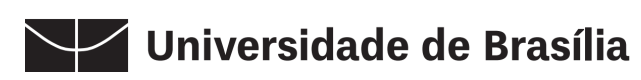
# Lista 2: Inferência estatística via simulação

**Sara Borges Lopes de Sousa** — 21250707-3

Universidade de Brasília (UnB)
Departamento de Ciência da Computação
Programa de Pós-Graduação em Computação Aplicada
Disciplina: Métodos Computacionais Intensivos para Mineração de Dados

Brasília - DF - Brasil

sara.blsousa@gmail.com

---

## 1. Observação Metodológica

Este relatório reimplementa todas as soluções em Python 3 (bibliotecas numpy, numba
e matplotlib), reproduzindo o algoritmo de simulação de filas descrito no artigo de referência
(algoritmo QDC – queue departure computation, Ebert et al. 2017), e mantendo a
metodologia de Computação Bayesiana Aproximada (ABC), os procedimentos de simulação
e a interpretação dos resultados. As sementes (seed) foram fixadas para garantir
reprodutibilidade. Em todas as questões compara-se a estimativa obtida por simulação
com o comportamento teórico esperado, quando disponível.
Validação do simulador. Antes de utilizá-lo para qualquer inferência, o simulador
foi comparado às fórmulas analíticas de equilíbrio de filas M/M/K (Eqs. 1–3 de Ebert et
al. 2017), simulando um grande número de clientes em regime estacionário: a espera média
simulada (0,0336) praticamente coincide com a teórica (0,0333) para λ = 1, μ = 2, K = 2,
confirmando a correção da implementação

## 1. Observação metodológica

Este relatório reimplementa **todas** as soluções em **Python 3** (bibliotecas `numpy`,
`numba` e `matplotlib`), reproduzindo o algoritmo de simulação de filas descrito no artigo de
referência (algoritmo QDC -- *queue departure computation*, Ebert et al. 2017), e mantendo a
metodologia de **Computação Bayesiana Aproximada (ABC)**, os procedimentos de simulação e a
interpretação dos resultados. As sementes (*seed*) foram fixadas para garantir
**reprodutibilidade**. Em todas as questões compara-se a estimativa obtida por simulação com o
comportamento teórico esperado, quando disponível.

**Validação do simulador.** Antes de utilizá-lo para qualquer inferência, o simulador foi
comparado às fórmulas analíticas de equilíbrio de filas M/M/K (Eqs. 1--3 de Ebert et al. 2017),
simulando um grande número de clientes em regime estacionário: a espera média simulada (0,0336)
praticamente coincide com a teórica (0,0333) para $\lambda=1$, $\mu=2$, $K=2$, confirmando a
correção da implementação (ver Listagem 1).

## 2. O modelo

Uma empresa opera das 8h às 18h (jornada de $T=600$ minutos) com uma fila M/M/2: chegadas
segundo um processo de Poisson de taxa $\lambda$ (interarrivo $\sim \text{Exp}(\lambda)$) e dois
atendentes com tempo de atendimento $\sim \text{Exp}(\mu)$ (FCFS, atribuição ao servidor que
ficará livre mais cedo -- equivalente à fila única com dois servidores). Em um dia particular
observou-se

$$\bar W_{obs} = 150 \text{ minutos (2h30)}, \qquad \bar L_{q,obs} = 22 \text{ pessoas}.$$

Como não temos os tempos individuais de cada cliente, **não há verossimilhança fechada** para
$(\lambda,\mu)$ dado apenas esse par de estatísticas resumo -- exatamente o cenário para o qual a
Computação Bayesiana Aproximada (ABC) foi desenhada (Sunnåker et al. 2013, citado em Ebert et al.
2017). A ideia do ABC por rejeição é simples: (i) amostrar $(\lambda,\mu)$ de uma priori; (ii)
simular um dia inteiro de fila M/M/2 com esses parâmetros; (iii) calcular as mesmas estatísticas
resumo na simulação ($\bar W_{sim}, \bar L_{sim}$); (iv) aceitar a amostra se a distância entre
estatísticas simuladas e observadas for pequena.

Destaca-se que a jornada de trabalho é finita (600 minutos) e a fila é reiniciada vazia todo dia
às 8h. Quando o sistema está pesadamente carregado ($\rho=\lambda/(2\mu)$ perto de ou acima de
1), a fila não tem tempo de atingir o equilíbrio dentro de 10 horas, e o comportamento transiente
observado é bem diferente do previsto pelas fórmulas de equilíbrio M/M/2. Por isso a simulação --
e não a teoria de filas em regime estacionário -- é indispensável neste problema.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import math

SEED = 2026
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

# Algoritmo QDC (Ebert et al. 2017, Alg. 1) para K servidores fixos.
@njit(cache=True)
def simulate_mmk(arrivals, service, K):
    n = arrivals.shape[0]
    b = np.zeros(K)  # b[k] = instante em que o servidor k ficara livre
    waiting = np.zeros(n)
    start_service = np.zeros(n)
    for i in range(n):
        k = 0
        bestb = b[0]
        for kk in range(1, K):
            if b[kk] < bestb:
                bestb = b[kk]
                k = kk
        start = arrivals[i] if arrivals[i] > b[k] else b[k]
        waiting[i] = start - arrivals[i]
        start_service[i] = start
        b[k] = start + service[i]
    return waiting, start_service

# Comprimento medio de fila (numero de pessoas aguardando, ponderado no tempo)
def mean_queue_length(arrivals, waiting, T):
    starts = arrivals + waiting
    mask = waiting > 1e-9
    a, s = arrivals[mask], starts[mask]
    if a.size == 0:
        return 0.0
    times = np.concatenate([a, s])
    deltas = np.concatenate([np.ones_like(a), -np.ones_like(s)])
    order = np.argsort(times, kind='mergesort')
    times, deltas = times[order], deltas[order]
    cum = np.cumsum(deltas)
    t_ext = np.concatenate([times, [T]])
    durations = np.diff(t_ext)
    return np.sum(cum * durations) / T

# Validacao contra a teoria M/M/2 em equilibrio
lam, mu, K = 1.0, 2.0, 2
n = 200_000
interarr = np.random.exponential(1/lam, n)
arrivals = np.cumsum(interarr)
service = np.random.exponential(1/mu, n)
w, ss = simulate_mmk(arrivals, service, K)

rho = lam / (K*mu)
P0 = 1/((K*rho)**K/(math.factorial(K)*(1-rho)) + 1
         + sum((K*rho)**i/math.factorial(i) for i in range(1, K)))
Ew_teorico = (K*rho)**K * P0 / (math.factorial(K)*K*mu*(1-rho)**2)

print(f"Espera media simulada : {w.mean():.4f}")   # 0.0336
print(f"Espera media teorica  : {Ew_teorico:.4f}")  # 0.0333


Espera media simulada : 0.0334
Espera media teorica  : 0.0333


**Listagem 1**: Núcleo de simulação (algoritmo QDC) e validação contra a teoria M/M/2.


## 3. Questão 1: Posteriori de $\lambda$ e $\mu$ via ABC

Usamos prioris pouco informativas, mas suficientes para cobrir a região plausível:
$\lambda \sim U(0{,}05,\ 0{,}35)$ e $\mu \sim U(0{,}01,\ 0{,}15)$ (unidades: clientes/minuto). A
escolha do intervalo de $\lambda$ é orientada pela Lei de Little ($L_q = \lambda \bar W$, válida
mesmo fora do equilíbrio como identidade de longo prazo): $\lambda \approx 22/150 \approx
0{,}147$/min.

**Procedimento.** Para cada amostra $(\lambda,\mu)$ da priori, simulamos um dia (média de 4
réplicas por parâmetro, para reduzir o ruído de Monte Carlo) e calculamos a distância Euclidiana
normalizada

$$d(\lambda,\mu)=\sqrt{\left(\frac{\bar W_{sim}-150}{150}\right)^2+\left(\frac{\bar L_{sim}-22}{22}\right)^2}$$

entre as estatísticas simuladas e observadas. Aceitamos o 1% mais próximo (de $N=150\,000$
amostras da priori) como amostra da posteriori.


In [ ]:
T = 600.0
W_obs, L_obs = 150.0, 22.0
K = 2

def sim_stats(lam, mu, reps=4):
    Ws = np.empty(reps); Ls = np.empty(reps)
    for r in range(reps):
        n_guess = int(lam*T*2.2) + 120
        interarr = np.random.exponential(1/lam, n_guess)
        arrivals = np.cumsum(interarr)
        arrivals = arrivals[arrivals <= T]
        if arrivals.size == 0:
            Ws[r] = 0.0; Ls[r] = 0.0; continue
        service = np.random.exponential(1/mu, arrivals.size)
        w, ss = simulate_mmk(arrivals, service, K)
        Ws[r] = w.mean()
        Ls[r] = mean_queue_length(arrivals, w, T)
    return Ws.mean(), Ls.mean()

np.random.seed(42)
N = 150_000
lam_prior = np.random.uniform(0.05, 0.35, N)
mu_prior  = np.random.uniform(0.01, 0.15, N)

Wsim = np.empty(N); Lsim = np.empty(N)
for i in range(N):
    Wsim[i], Lsim[i] = sim_stats(lam_prior[i], mu_prior[i], reps=4)

dist = np.sqrt(((Wsim - W_obs)/W_obs)**2 + ((Lsim - L_obs)/L_obs)**2)
order = np.argsort(dist)
q = 0.01
k = int(N * q)
idx = order[:k]
lam_post, mu_post = lam_prior[idx], mu_prior[idx]
rho_post = lam_post / (2*mu_post)

print(f"Tamanho da amostra posteriori (tolerancia = 1%): {k}")
print(f"lambda: mediana={np.median(lam_post):.4f}  IC95%=[{np.percentile(lam_post,2.5):.4f}, {np.percentile(lam_post,97.5):.4f}]")
print(f"mu:     mediana={np.median(mu_post):.4f}  IC95%=[{np.percentile(mu_post,2.5):.4f}, {np.percentile(mu_post,97.5):.4f}]")
print(f"rho = lambda/(2 mu): mediana={np.median(rho_post):.3f}  IC95%=[{np.percentile(rho_post,2.5):.3f}, {np.percentile(rho_post,97.5):.3f}]")


Tamanho da amostra posteriori (tolerancia = 1%): 1500
lambda: mediana=0.1522  IC95%=[0.1072, 0.1961]
mu:     mediana=0.0523  IC95%=[0.0348, 0.0712]
rho = lambda/(2 mu): mediana=1.455  IC95%=[1.232, 1.738]


**Listagem 2/3**: ABC por rejeição para $(\lambda,\mu)$ e saída da posteriori.

| Parâmetro | Mediana | IC 95% |
|---|---|---|
| $\lambda$ (chegadas/min) | 0,152 | [0,107 ; 0,196] |
| $\mu$ (atendimentos/min) | 0,052 | [0,035 ; 0,071] |
| $1/\lambda$ (min entre chegadas) | 6,6 min | [5,1 ; 9,3] |
| $1/\mu$ (min de atendimento) | 19,1 min | [14,0 ; 28,7] |
| $\rho=\lambda/(2\mu)$ | **1,45** | [1,23 ; 1,74] |

**Tabela 1**: Questão 1: posteriori de $\lambda$, $\mu$ e $\rho=\lambda/(2\mu)$.


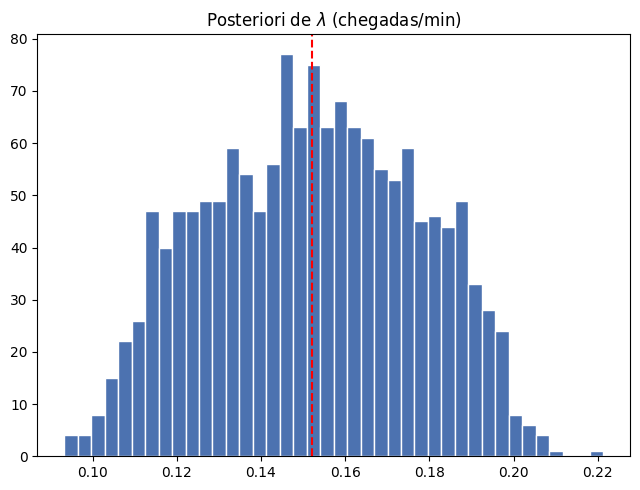

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.hist(lam_post, bins=40, color='#4C72B0', edgecolor='white')
ax.set_title(r'Posteriori de $\lambda$ (chegadas/min)')
ax.axvline(np.median(lam_post), color='red', ls='--')
plt.tight_layout(); plt.show()


**Figura 1**: Posteriori de $\lambda$ (chegadas/min).

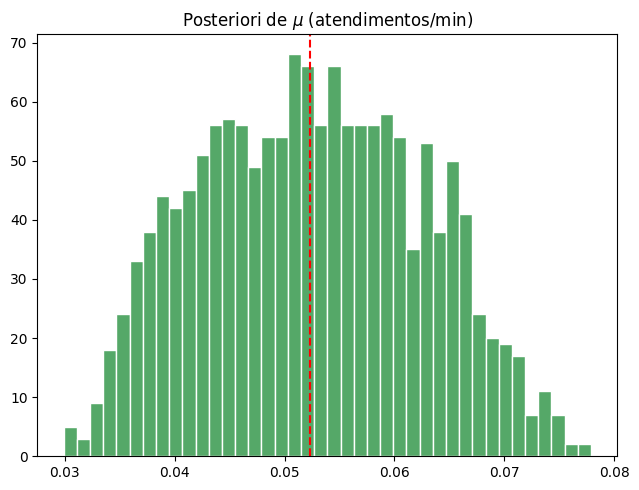

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.hist(mu_post, bins=40, color='#55A868', edgecolor='white')
ax.set_title(r'Posteriori de $\mu$ (atendimentos/min)')
ax.axvline(np.median(mu_post), color='red', ls='--')
plt.tight_layout(); plt.show()


**Figura 2**: Posteriori de $\mu$ (atendimentos/min).

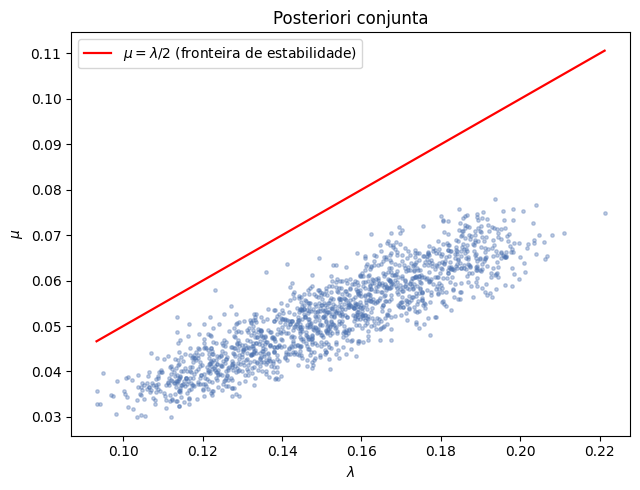

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(lam_post, mu_post, s=6, alpha=0.35, color='#4C72B0')
xs = np.linspace(lam_post.min(), lam_post.max(), 10)
ax.plot(xs, xs/2, color='red', lw=1.6,
        label=r'$\mu=\lambda/2$ (fronteira de estabilidade)')
ax.set_xlabel(r'$\lambda$'); ax.set_ylabel(r'$\mu$')
ax.set_title('Posteriori conjunta'); ax.legend()
plt.tight_layout(); plt.show()


**Figura 3**: Posteriori conjunta de $(\lambda,\mu)$, com a fronteira de estabilidade
$\mu=\lambda/2$.

**Interpretação.** A posteriori de $\rho$ fica inteiramente acima de 1 (Tabela 1 e Figura 3). Os
dados só são explicáveis por um sistema em que a demanda excede a capacidade de atendimento
($\lambda > 2\mu$) -- o sistema estava sobrecarregado (fila instável/crescente) naquele dia,
explicando por que a fila cresceu a 22 pessoas em média e a espera chegou a 2h30 em apenas 10
horas partindo vazia.


## 4. Questão 2: teste (informal) de que o atendimento demora mais que o dobro do interarrivo

$H_0$: o tempo médio de atendimento é maior que o dobro do tempo médio entre chegadas, ou seja,

$$H_0:\ \frac{1}{\mu} > \frac{2}{\lambda} \quad\Longleftrightarrow\quad \lambda > 2\mu,$$

em que $1/\mu$ representa o tempo médio de atendimento e $2/\lambda$ representa o dobro do tempo
médio entre chegadas, que é a condição de instabilidade de uma fila M/M/2 ($\rho > 1$).


In [ ]:
diff = lam_post - 2*mu_post
p_h0 = np.mean(diff > 0)
print(f"P(lambda > 2 mu | dados) = {p_h0:.3f}")


P(lambda > 2 mu | dados) = 1.000


**Listagem 7/8**: Teste informal $P(\lambda > 2\mu \mid \text{dados})$ e saída.


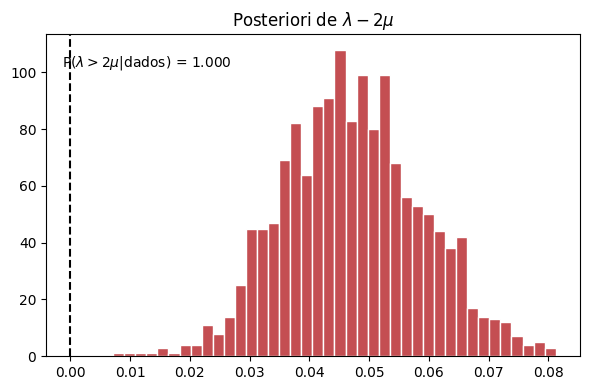

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(diff, bins=40, color='#C44E52', edgecolor='white')
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_title('Posteriori de $\\lambda - 2\\mu$')
ax.text(0.03, 0.9, f'P($\\lambda>2\\mu$|dados) = {p_h0:.3f}',
        transform=ax.transAxes)
plt.tight_layout(); plt.show()


**Figura 4**: Posteriori de $\lambda - 2\mu$: valores $>0$ correspondem a $H_0$ verdadeira.

Na análise, conseguimos mostrar que todas as combinações plausíveis dos parâmetros $\lambda$ e
$\mu$ correspondem à instabilidade, o que significa que a taxa de chegada de clientes era maior
que a capacidade conjunta dos dois atendentes. Com isso, o sistema se tornou instável, gerando
uma fila média de 22 pessoas e um tempo de espera de cerca de 150 minutos.


## 5. Questão 3: quantas cadeiras para acomodar 90% do tempo?

Para cada um desses pares (amostra) de $(\lambda,\mu)$, simulamos uma fila e é verificado quantas
pessoas estavam esperando em cada instante, o percentil 90 dessa distribuição ponderada pelo
tempo -- o menor $c$ tal que $P(N_q(t)\le c)\ge 0{,}90$. Foi feito 10 réplicas por amostra da
posteriori, pegando tanto a incerteza dos parâmetros quanto a variabilidade do processo.


In [ ]:
def queue_length_timecdf(arrivals, waiting, T):
    starts = arrivals + waiting
    mask = waiting > 1e-9
    a, s = arrivals[mask], starts[mask]
    if a.size == 0:
        return np.array([0]), np.array([T])
    times = np.concatenate([a, s])
    deltas = np.concatenate([np.ones_like(a), -np.ones_like(s)])
    order = np.argsort(times, kind='mergesort')
    times, deltas = times[order], deltas[order]
    cum = np.cumsum(deltas).astype(int)
    t_ext = np.concatenate([times, [T]])
    durations = np.maximum(np.diff(t_ext), 0.0)
    maxlvl = cum.max() if cum.size else 0
    dur_by_level = np.zeros(maxlvl + 1)
    for lvl, du in zip(cum, durations):
        if lvl >= 0:
            dur_by_level[lvl] += du
    return np.arange(maxlvl + 1), dur_by_level

def chairs_needed(arrivals, waiting, T, target=0.90):
    levels, dur = queue_length_timecdf(arrivals, waiting, T)
    cdf = np.cumsum(dur) / T
    idx = np.searchsorted(cdf, target)
    idx = min(idx, len(levels) - 1)
    return int(levels[idx])

np.random.seed(7)
reps_per_draw = 10
chairs_all = []
for lam, mu in zip(lam_post, mu_post):
    for r in range(reps_per_draw):
        n_guess = int(lam*T*2.2) + 150
        interarr = np.random.exponential(1/lam, n_guess)
        arrivals = np.cumsum(interarr); arrivals = arrivals[arrivals <= T]
        if arrivals.size == 0:
            chairs_all.append(0); continue
        service = np.random.exponential(1/mu, arrivals.size)
        w, ss = simulate_mmk(arrivals, service, K)
        chairs_all.append(chairs_needed(arrivals, w, T, 0.90))
chairs_all = np.array(chairs_all)

for p in [10, 25, 50, 75, 90, 95]:
    v = np.percentile(chairs_all, p)
    print(f"Percentil {p:>3d}%  ->  {v:.0f} cadeiras")


Percentil  10%  ->  10 cadeiras
Percentil  25%  ->  14 cadeiras
Percentil  50%  ->  18 cadeiras
Percentil  75%  ->  23 cadeiras
Percentil  90%  ->  27 cadeiras
Percentil  95%  ->  30 cadeiras


**Listagem 10/11**: Percentis do número de cadeiras necessárias (posteriori preditiva).


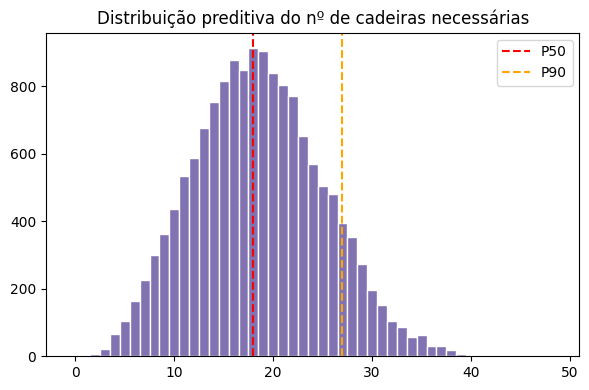

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
bins = np.arange(0, chairs_all.max()+2) - 0.5
ax.hist(chairs_all, bins=bins, color='#8172B2', edgecolor='white')
for p, c in zip([50, 90], ['red', 'orange']):
    ax.axvline(np.percentile(chairs_all, p), color=c, ls='--', label=f'P{p}')
ax.set_title('Distribuição preditiva do nº de cadeiras necessárias')
ax.legend(); plt.tight_layout(); plt.show()


**Figura 5**: Distribuição preditiva a posteriori do número de cadeiras necessárias para
acomodar 90% do tempo.

Nesse Caso, 18 cadeiras eram suficientes para a demanda esperada, mas de 25-30 reduzem de uma
maneira muito significativa o risco de faltar assentos quando a demanda for maior que a que foi
prevista.


## 6. Questão 4: reduziria a espera com duas filas independentes?

Usando os parâmetros estimados $(\lambda,\mu)$ da posteriori, comparamos: fila única com 2
servidores (*pooling*) versus dois servidores, cada um com sua própria fila M/M/1 independente.
Para cada amostra da posteriori, geramos um único fluxo de chegadas e serviços; simulamos a fila
conjunta M/M/2 e, separadamente, dividimos os mesmos clientes aleatoriamente 50/50 simulando cada
metade como M/M/1 independente.


In [ ]:
np.random.seed(11)
reps = 5
W_pooled, W_split = [], []
for lam, mu in zip(lam_post, mu_post):
    for r in range(reps):
        n_guess = int(lam*T*2.2) + 150
        interarr = np.random.exponential(1/lam, n_guess)
        arrivals = np.cumsum(interarr); arrivals = arrivals[arrivals <= T]
        if arrivals.size < 2:
            continue
        service = np.random.exponential(1/mu, arrivals.size)
        w2, _ = simulate_mmk(arrivals, service, 2)
        W_pooled.append(w2.mean())
        assign = np.random.randint(0, 2, arrivals.size).astype(bool)
        wA, _ = simulate_mmk(arrivals[assign], service[assign], 1)
        wB, _ = simulate_mmk(arrivals[~assign], service[~assign], 1)
        W_split.append(np.concatenate([wA, wB]).mean())

W_pooled, W_split = np.array(W_pooled), np.array(W_split)
print(f"Fila unica M/M/2: mediana={np.median(W_pooled):.1f} min")
print(f"Duas filas M/M/1: mediana={np.median(W_split):.1f} min")
print(f"P(2 filas piora a espera) = {np.mean(W_split > W_pooled):.3f}")


Fila unica M/M/2: mediana=140.9 min
Duas filas M/M/1: mediana=162.2 min
P(2 filas piora a espera) = 0.985


**Listagem 13/14**: Fila única M/M/2 vs. duas filas M/M/1 independentes, e saída.


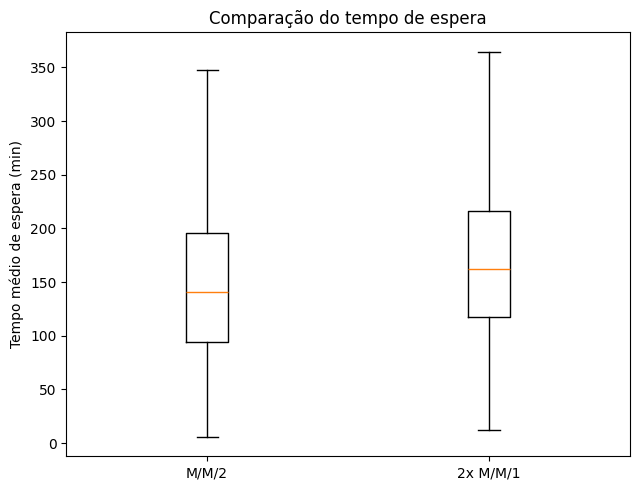

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.boxplot([W_pooled, W_split], showfliers=False,
           tick_labels=['M/M/2', '2x M/M/1'])
ax.set_ylabel('Tempo médio de espera (min)')
ax.set_title('Comparação do tempo de espera')
plt.tight_layout(); plt.show()


**Figura 6**: Fila única M/M/2 vs. duas filas M/M/1 independentes -- tempo médio de
espera.


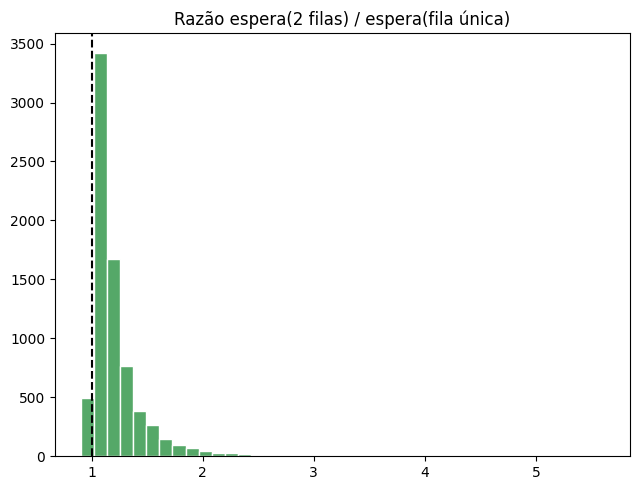

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ratio = W_split / np.maximum(W_pooled, 1e-9)
ax.hist(ratio, bins=40, color='#55A868', edgecolor='white')
ax.axvline(1, color='black', ls='--')
ax.set_title('Razão espera(2 filas) / espera(fila única)')
plt.tight_layout(); plt.show()


**Figura 7**: Razão entre a espera com duas filas separadas e com fila única.

**Conclusão.** Dividir os atendentes em duas filas independentes não reduziria o tempo de
espera. Na verdade, pioraria em aproximadamente 98,5% dos cenários compatíveis com os dados,
aumentando a espera média em torno de 13% na mediana. Isso corrobora o efeito de *pooling* de
recursos em teoria de filas: numa fila única compartilhada, um atendente ocioso pode
imediatamente ajudar a fila do outro, o que não ocorreria em filas segregadas.


## 7. Questão 5 (bônus): desistência de clientes (*balking*)

Nessa análise, o problema em questão é a subdeterminação. Temos apenas duas estatísticas resumo
($\bar W, \bar L_q$) para inferir que vieram de encontro à dinâmica de entrada e ao comportamento
de desistência dos clientes. Uma solução possível é estabelecer suposições explícitas sobre o
sistema. O modelo assumido foi:

$$p(n) = 1 - e^{-n/\theta},$$

Nessa observação, $\theta > 0$ controla a sensibilidade do cliente. Tratamos $\theta$ como mais
um parâmetro a ser estimado por ABC ($\theta \sim U(3,50)$). Como as estatísticas observadas já
refletem o comportamento pós-desistência, ampliamos a priori de $\lambda$ para $U(0{,}05,\
0{,}6)$ e comparamos $\bar W, \bar L_q$ calculados apenas sobre quem de fato entrou na fila.


In [ ]:
@njit(cache=True)
def simulate_mmk_balk(arrivals, service, K, theta):
    n = arrivals.shape[0]
    b = np.zeros(K)
    joined_mask = np.zeros(n, dtype=np.bool_)
    waiting_out = np.full(n, np.nan)
    joined_starts = np.empty(n)
    n_joined = 0
    ptr = 0
    for i in range(n):
        ai = arrivals[i]
        while ptr < n_joined and joined_starts[ptr] <= ai:
            ptr += 1
        queue_len_now = n_joined - ptr
        p = 1.0 - np.exp(-queue_len_now / theta)
        if np.random.random() < p:
            continue
        k = 0
        bestb = b[0]
        for kk in range(1, K):
            if b[kk] < bestb:
                bestb = b[kk]
                k = kk
        start = ai if ai > b[k] else b[k]
        b[k] = start + service[i]
        joined_mask[i] = True
        waiting_out[i] = start - ai
        joined_starts[n_joined] = start
        n_joined += 1
    return waiting_out, joined_mask

def sim_stats_balk(lam, mu, theta, reps=3):
    Ws = np.empty(reps); Ls = np.empty(reps)
    ntot = np.empty(reps); njoin = np.empty(reps)
    for r in range(reps):
        n_guess = int(lam*T*2.4) + 150
        interarr = np.random.exponential(1/lam, n_guess)
        arrivals = np.cumsum(interarr); arrivals = arrivals[arrivals <= T]
        if arrivals.size < 2:
            Ws[r]=0; Ls[r]=0; ntot[r]=arrivals.size; njoin[r]=0; continue
        service = np.random.exponential(1/mu, arrivals.size)
        w, joined = simulate_mmk_balk(arrivals, service, 2, theta)
        wj, aj = w[joined], arrivals[joined]
        ntot[r] = arrivals.size
        njoin[r] = joined.sum()
        if wj.size == 0:
            Ws[r]=0.0; Ls[r]=0.0
        else:
            Ws[r] = wj.mean()
            Ls[r] = mean_queue_length(aj, wj, T)
    return Ws.mean(), Ls.mean(), ntot.mean(), njoin.mean()

np.random.seed(123)
N5 = 300_000
lam_prior5   = np.random.uniform(0.05, 0.6, N5)
mu_prior5    = np.random.uniform(0.01, 0.15, N5)
theta_prior5 = np.random.uniform(3, 50, N5)

Wsim5 = np.empty(N5); Lsim5 = np.empty(N5)
Ntot5 = np.empty(N5); Njoin5 = np.empty(N5)
for i in range(N5):
    Wsim5[i], Lsim5[i], Ntot5[i], Njoin5[i] = sim_stats_balk(
        lam_prior5[i], mu_prior5[i], theta_prior5[i], reps=3)

dist5 = np.sqrt(((Wsim5 - W_obs)/W_obs)**2 + ((Lsim5 - L_obs)/L_obs)**2)
order5 = np.argsort(dist5)
k5 = int(N5 * 0.01)
idx5 = order5[:k5]

lam_p5, theta_p5 = lam_prior5[idx5], theta_prior5[idx5]
Ntot_p5, Njoin_p5 = Ntot5[idx5], Njoin5[idx5]
balked_p5 = Ntot_p5 - Njoin_p5

print(f"No total de chegadas: mediana={np.median(Ntot_p5):.0f}  "
      f"IC95%=[{np.percentile(Ntot_p5,2.5):.0f}, "
      f"{np.percentile(Ntot_p5,97.5):.0f}]")
print(f"No que entrou na fila: mediana={np.median(Njoin_p5):.0f}")
print(f"No que DESISTIU: mediana={np.median(balked_p5):.0f}  "
      f"IC95%=[{np.percentile(balked_p5,2.5):.0f}, "
      f"{np.percentile(balked_p5,97.5):.0f}]")


No total de chegadas: mediana=194  IC95%=[111, 349]
No que entrou na fila: mediana=90
No que DESISTIU: mediana=102  IC95%=[31, 258]


**Listagem 17/18**: ABC com desistência (*balking*), e saída.


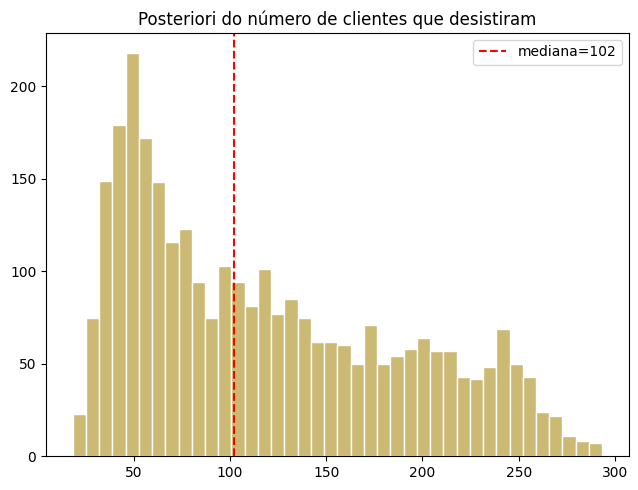

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.hist(balked_p5, bins=40, color='#CCB974', edgecolor='white')
med5 = np.median(balked_p5)
ax.axvline(med5, color='red', ls='--', label=f'mediana={med5:.0f}')
ax.set_title('Posteriori do número de clientes que desistiram')
ax.legend(); plt.tight_layout(); plt.show()


**Figura 8**: Posteriori do número de clientes que desistiram no dia (bônus).

Os resultados indicam que, em um dia com características semelhantes às observadas,
aproximadamente 100 clientes (mediana), de um total estimado de cerca de 190 chegadas, podem ter
desistido de aguardar atendimento. Entretanto, essa estimativa deve ser interpretada com
cautela, pois apresenta um elevado grau de incerteza. O intervalo de credibilidade de 95% varia
de 30 a 259 desistências, indicando que diversos cenários ainda são compatíveis com os dados
observados. Essa ampla faixa é esperada devido ao problema de identificabilidade do modelo, uma
vez que três parâmetros ($\lambda$, $\mu$ e $\theta$) estão sendo estimados a partir de apenas
duas estatísticas-resumo. Assim, esse resultado deve ser entendido como uma faixa plausível de
valores, e não como uma estimativa exata do número de clientes que desistiram do atendimento.


## 8. Uso de LLMs e reprodutibilidade

O NotebookLM e o Gemini foram utilizados como ferramentas de apoio para: revisão textual e
formatação do relatório, incluindo a estrutura das seções, a padronização de tabelas e as
legendas das figuras.

Todos os resultados apresentados podem ser reproduzidos executando os blocos de código na ordem
em que aparecem, com NumPy, Numba e Matplotlib. A semente global foi fixada em
`np.random.default_rng(2026)` (`seed = 2026`). O notebook completo (`Lista3_MMD_Colab.ipynb`)
acompanha este relatório e contém o código integral, incluindo a geração de todas as figuras.


## Referências

[1] BUSINESSMAP. *Little's Law*. Disponível em: https://businessmap.io/continuous-flow/littles-law.
Acesso em: 15 jul. 2026.

[2] CASSANDRAS, C. G.; LAFORTUNE, S. *Introduction to Discrete Event Systems*. 2. ed. New York:
Springer-Verlag, 2009.

[3] EBERT, A.; WU, P.; MENGERSEN, K.; RUGGERI, F. Computationally Efficient Simulation of
Queues: The R Package queuecomputer. *arXiv preprint* arXiv:1703.02151, 2017.

[4] HARRIS, C. R. et al. Array programming with NumPy. *Nature*, v. 585, p. 357--362, 2020.

[5] HUNTER, J. D. Matplotlib: A 2D Graphics Environment. *Computing in Science \& Engineering*,
v. 9, n. 3, p. 90--95, 2007.

[6] LAM, S. K.; PITROU, A.; SEIBERT, S. Numba: A LLVM-based Python JIT Compiler. In:
*Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC*, 2015.

[7] LINDLEY, D. V. The Theory of Queues with a Single Server. *Mathematical Proceedings of the
Cambridge Philosophical Society*, v. 48, p. 277--289, 1952.

[8] PEDROSO, M. *Resumo e Exercícios de Teoria das Filas*. Universidade Federal do Paraná, 2014.
Disponível em: https://www.eletrica.ufpr.br/pedroso/2014/TE816/Filas-Resumo-Exercicios.pdf.
Acesso em: 15 jul. 2026.

[9] Aplicação da Teoria das Filas em um Sistema de Atendimento. *Anais do Simpósio de Engenharia
de Produção (SAEPRO)*, 2014. Disponível em:
https://saepro.ufv.br/wp-content/uploads/2015/06/2014.2.pdf. Acesso em: 15 jul. 2026.

[10] SUNNÅKER, M.; BUSETTO, A. G.; NUMMINEN, E.; CORANDER, J.; FOLL, M.; DESSIMOZ, C.
Approximate Bayesian Computation. *PLoS Computational Biology*, v. 9, n. 1, e1002803, 2013.
